In [2]:
import numpy as np
a=np.array([[4,7],[2,6]])
print(" matrix A: ",a)
#find determinant
det=np.linalg.det(a)
print(" determinant of matrix: ",det)
#check if inverse exist
if det==0:
    print(" inverse doesnt exist(singular matrix)")
else:
    print(" inverse exists")
#compute inverse
a_inv=np.linalg.inv(a)
print(" inverse of a : ",a_inv)
#verify res
identity=np.dot(a,a_inv)
print(" verification (a*a_inv): ",identity)

 matrix A:  [[4 7]
 [2 6]]
 determinant of matrix:  10.000000000000002
 inverse exists
 inverse of a :  [[ 0.6 -0.7]
 [-0.2  0.4]]
 verification (a*a_inv):  [[ 1.00000000e+00  0.00000000e+00]
 [-2.22044605e-16  1.00000000e+00]]


original matrix: [[2 8]
 [3 7]
 [4 6]
 [5 5]]
mean: [3.5 6.5]
mean centered data:
 [[-1.5  1.5]
 [-0.5  0.5]
 [ 0.5 -0.5]
 [ 1.5 -1.5]]
covariance matrix (1/n):
 [[ 1.25 -1.25]
 [-1.25  1.25]]
covariance matrix (built-in 1/(n-1)):
 [[ 1.25 -1.25]
 [-1.25  1.25]]
eigen values: [2.50000000e+00 2.22044605e-16]
eigen vectors:
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
principal eigen vector: [ 0.70710678 -0.70710678]
reduced data:
 [-2.12132034 -0.70710678  0.70710678  2.12132034]


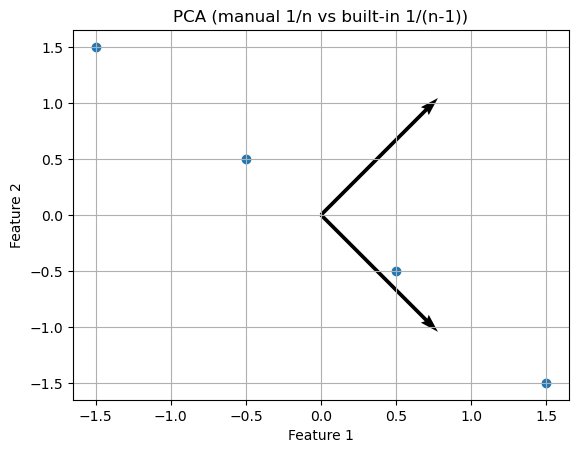

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# original data
x = np.array([[2,8],[3,7],[4,6],[5,5]])
print("original matrix:", x)

# mean centering
mean = np.mean(x, axis=0)
x_centered = x - mean
print("mean:", mean)
print("mean centered data:\n", x_centered)

# covariance matrix using (1/n)
n = x_centered.shape[0]
cov_mat = (1/n) * np.dot(x_centered.T, x_centered)
print("covariance matrix (1/n):\n", cov_mat)

# covariance using built-in (default uses 1/(n-1))
cov_mat_b = np.cov(x_centered.T,bias=True)
print("covariance matrix (built-in 1/(n-1)):\n", cov_mat_b)

# eigenvalues and eigenvectors
eig_val, eig_vec = np.linalg.eig(cov_mat)
print("eigen values:", eig_val)
print("eigen vectors:\n", eig_vec)

# select principal component (largest eigenvalue)
idx = np.argmax(eig_val)
principal_vec = eig_vec[:, idx]
print("principal eigen vector:", principal_vec)

# project data onto principal component
x_reduced = np.dot(x_centered, principal_vec)
print("reduced data:\n", x_reduced)

# visualization
plt.figure()

# plot centered data
plt.scatter(x_centered[:,0], x_centered[:,1])

# plot eigenvectors
origin = [0, 0]
plt.quiver(*origin, eig_vec[0,0], eig_vec[1,0], scale=3)
plt.quiver(*origin, eig_vec[0,1], eig_vec[1,1], scale=3)

# labels
plt.title("PCA (manual 1/n vs built-in 1/(n-1))")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid()

plt.show()

original shape: (1797, 64)
reduced shape: (1797, 18)


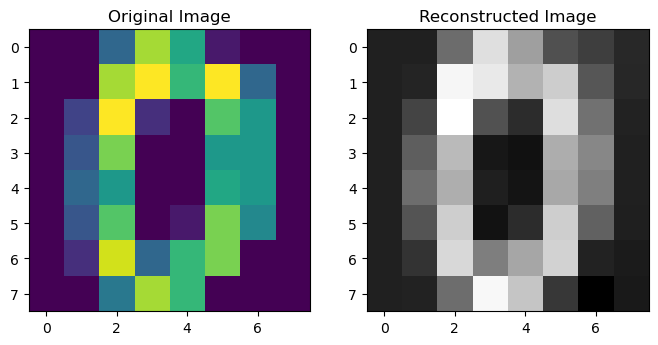

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# load dataset
digits = load_digits()
x = digits.data   # (1797, 64)
y = digits.target

print("original shape:", x.shape)

# apply PCA
pca = PCA(n_components=18)
x_pca = pca.fit_transform(x)

print("reduced shape:", x_pca.shape)
# reconstruct image
x_reconstructed = pca.inverse_transform(x_pca)

# display original vs reconstructed
plt.figure(figsize=(8,4))

# original image
plt.subplot(1,2,1)
plt.imshow(x[0].reshape(8,8))
plt.title("Original Image")

# reconstructed image
plt.subplot(1,2,2)
plt.imshow(x_reconstructed[0].reshape(8,8), cmap='gray')
plt.title("Reconstructed Image")

plt.show()